# Population Analysis — Italian Real Estate Market

Build a reproducible **municipality-year population panel** from the ISTAT POSAS releases stored in the repository.

**Pipeline:** raw population-by-age files → inventory → validation → municipality totals → demographic indicators → geographic analysis → analytical hand-off.

The municipality files contain one row per age and an official `Età = 999` total row.


## 1. Setup and source inventory

Years and files are discovered automatically so the notebook remains reproducible when a new annual release is added.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'population'
assert RAW_DIR.exists(), f'Population directory not found: {RAW_DIR}'

YEAR_DIRS = sorted(p for p in RAW_DIR.iterdir() if p.is_dir() and p.name.isdigit())
YEARS = [int(p.name) for p in YEAR_DIRS]
print(f'Population releases: {min(YEARS)}–{max(YEARS)}')
print(f'Years available: {YEARS}')

inventory = []
for folder in YEAR_DIRS:
    files = sorted(folder.glob('*.csv'))
    inventory.append({
        'year': int(folder.name),
        'csv_files': len(files),
        'municipality_file': next((p.name for p in files if '_Comuni.csv' in p.name), pd.NA),
        'province_file': next((p.name for p in files if '_Province.csv' in p.name), pd.NA),
        'region_file': next((p.name for p in files if '_Regioni.csv' in p.name), pd.NA),
    })

inventory = pd.DataFrame(inventory)
display(inventory)
assert inventory[['municipality_file','province_file','region_file']].notna().all().all()

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


Population releases: 2019–2026
Years available: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


,year,csv_files,municipality_file,province_file,region_file
0,2019,3,POSAS_2019_it_Comuni.csv,POSAS_2019_it_Province.csv,POSAS_2019_it_Regioni.csv
1,2020,3,POSAS_2020_it_Comuni.csv,POSAS_2020_it_Province.csv,POSAS_2020_it_Regioni.csv
2,2021,3,POSAS_2021_it_Comuni.csv,POSAS_2021_it_Province.csv,POSAS_2021_it_Regioni.csv
3,2022,3,POSAS_2022_it_Comuni.csv,POSAS_2022_it_Province.csv,POSAS_2022_it_Regioni.csv
4,2023,3,POSAS_2023_it_Comuni.csv,POSAS_2023_it_Province.csv,POSAS_2023_it_Regioni.csv
5,2024,3,POSAS_2024_it_Comuni.csv,POSAS_2024_it_Province.csv,POSAS_2024_it_Regioni.csv
6,2025,3,POSAS_2025_it_Comuni.csv,POSAS_2025_it_Province.csv,POSAS_2025_it_Regioni.csv
7,2026,3,POSAS_2026_it_Comuni.csv,POSAS_2026_it_Province.csv,POSAS_2026_it_Regioni.csv


## 2. Municipality population panel

For the main market panel we use `Età = 999`, which represents the official municipality total. Reading only the required columns keeps the notebook substantially lighter than loading the full age-detail dataset into memory.


In [2]:
def load_municipality_totals(year):
    path = RAW_DIR / str(year) / f'POSAS_{year}_it_Comuni.csv'
    df = pd.read_csv(
        path, sep=';', encoding='utf-8-sig',
        usecols=['Codice comune','Comune','Età','Totale maschi','Totale femmine','Totale'],
    )
    df.columns = ['municipality_code','municipality','age','male','female','population']
    df['municipality_code'] = df['municipality_code'].astype('string').str.strip()
    df['municipality'] = df['municipality'].astype('string').str.strip()
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    df['population'] = pd.to_numeric(df['population'], errors='coerce')
    totals = df.loc[df['age'].eq(999)].copy()
    if totals['municipality_code'].duplicated().any():
        raise ValueError(f'{year}: duplicate municipality total keys')
    totals['year'] = year
    return totals[['year','municipality_code','municipality','population']]

municipality_panel = pd.concat(
    [load_municipality_totals(year) for year in YEARS],
    ignore_index=True,
)
print(f'Municipality-year observations: {len(municipality_panel):,}')
display(municipality_panel.head())


Municipality-year observations: 63,268


,year,municipality_code,municipality,population
0,2019,28001,Abano Terme,19841
1,2019,98001,Abbadia Cerreto,278
2,2019,97001,Abbadia Lariana,3200
3,2019,52001,Abbadia San Salvatore,6277
4,2019,95001,Abbasanta,2626


## 3. Data-quality controls

The key analytical invariant is one observation per **municipality + year**. Missing and duplicate keys are treated as structural errors, not silently repaired.


In [3]:
quality = pd.DataFrame({
    'metric': [
        'rows', 'unique municipality-year keys', 'missing municipality codes',
        'duplicate municipality-year keys', 'missing population',
        'negative population', 'years', 'municipalities in latest year'
    ],
    'value': [
        len(municipality_panel),
        municipality_panel[['year','municipality_code']].drop_duplicates().shape[0],
        municipality_panel['municipality_code'].isna().sum(),
        municipality_panel.duplicated(['year','municipality_code']).sum(),
        municipality_panel['population'].isna().sum(),
        (municipality_panel['population'] < 0).sum(),
        municipality_panel['year'].nunique(),
        municipality_panel.loc[municipality_panel['year'].eq(municipality_panel['year'].max()), 'municipality_code'].nunique(),
    ],
})
display(quality)
assert municipality_panel.duplicated(['year','municipality_code']).sum() == 0
assert municipality_panel['municipality_code'].notna().all()
assert municipality_panel['population'].notna().all()
assert (municipality_panel['population'] >= 0).all()


,metric,value
0,rows,63268
1,unique municipality-year keys,63268
2,missing municipality codes,0
3,duplicate municipality-year keys,0
4,missing population,0
5,negative population,0
6,years,8
7,municipalities in latest year,7896


## 4. National population trend

National population is obtained by summing municipality totals. A mean across municipalities would not have the same economic interpretation.


,year,population,municipalities,yoy_pct
0,2019,59816673,7954,NaN
1,2020,59641488,7914,-0.29
2,2021,59236213,7903,-0.68
3,2022,59030133,7904,-0.35
4,2023,58997201,7901,-0.06
5,2024,58971230,7900,-0.04
6,2025,58943464,7896,-0.05
7,2026,58942828,7896,-0.00


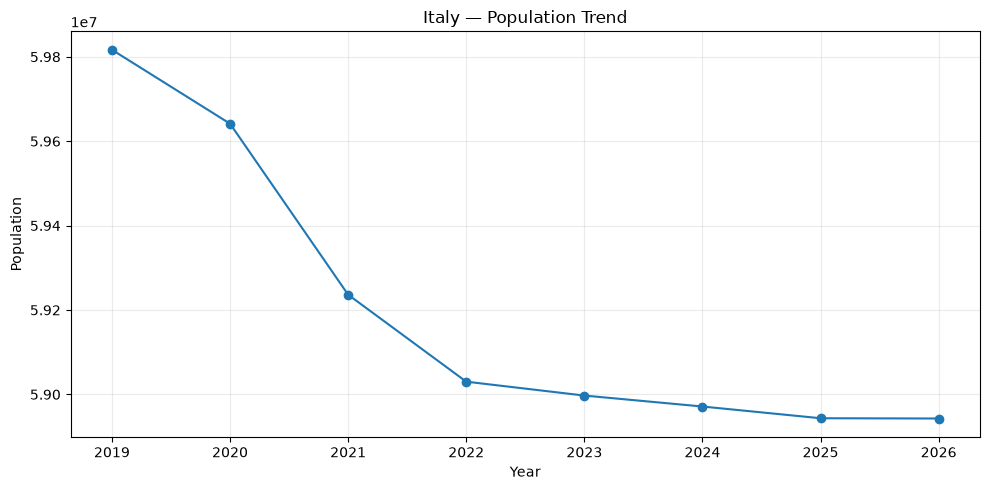

In [4]:
national_population = (
    municipality_panel.groupby('year', as_index=False)
    .agg(population=('population','sum'), municipalities=('municipality_code','nunique'))
)
national_population['yoy_pct'] = national_population['population'].pct_change() * 100
display(national_population)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(national_population['year'], national_population['population'], marker='o')
ax.set_title('Italy — Population Trend')
ax.set_xlabel('Year')
ax.set_ylabel('Population')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 5. Municipality demographic dynamics

Year-over-year changes expose geographic heterogeneity hidden by the national series. Absolute and percentage changes are both retained because percentage growth can be extreme for very small municipalities.


In [5]:
municipality_panel = municipality_panel.sort_values(['municipality_code','year']).reset_index(drop=True)
municipality_panel['population_change'] = municipality_panel.groupby('municipality_code')['population'].diff()
previous = municipality_panel.groupby('municipality_code')['population'].shift(1)
municipality_panel['population_change_pct'] = municipality_panel['population_change'].div(previous.where(previous.gt(0))).mul(100)

latest_year = municipality_panel['year'].max()
latest_dynamics = municipality_panel[municipality_panel['year'].eq(latest_year)].copy()

print('Largest absolute declines')
display(latest_dynamics.dropna(subset=['population_change']).sort_values('population_change').head(15))
print('Largest absolute increases')
display(latest_dynamics.dropna(subset=['population_change']).sort_values('population_change', ascending=False).head(15))


Largest absolute declines


,year,municipality_code,municipality,population,population_change,population_change_pct
42229,2026,63049,Napoli,905050,"-3,963.00",-0.44
9725,2026,15146,Milano,1362863,"-2,835.00",-0.21
55275,2026,82053,Palermo,626273,"-2,420.00",-0.38
37652,2026,58091,Roma,2745062,"-2,228.00",-0.08
57171,2026,87015,Catania,296984,"-1,070.00",-0.36
49517,2026,73027,Taranto,185112,-899.00,-0.48
53902,2026,80063,Reggio di Calabria,167925,-854.00,-0.51
59675,2026,92009,Cagliari,145981,-711.00,-0.48
42317,2026,63060,Pozzuoli,74665,-710.00,-0.94
33016,2026,49009,Livorno,152451,-703.00,-0.46


Largest absolute increases


,year,municipality_code,municipality,population,population_change,population_change_pct
6998,2026,1272,Torino,855654,"2,458.00",0.29
271,2026,10025,Genova,566247,"2,167.00",0.38
12390,2026,17029,Brescia,201342,"1,489.00",0.75
27633,2026,37006,Bologna,391473,"1,322.00",0.34
39,2026,100005,Prato,198327,"1,270.00",0.64
25872,2026,3106,Novara,103238,"1,007.00",0.99
38412,2026,6003,Alessandria,93409,887.00,0.96
23383,2026,28060,Padova,208202,790.00,0.38
26737,2026,34027,Parma,199450,757.00,0.38
27257,2026,36005,Carpi,74041,744.00,1.02


## 6. Population concentration

Population concentration provides a useful demographic context for subsequent real-estate analysis.


,municipality,population,national_share_pct
37652,Roma,2745062,4.66
9725,Milano,1362863,2.31
42229,Napoli,905050,1.54
6998,Torino,855654,1.45
55275,Palermo,626273,1.06
271,Genova,566247,0.96
27633,Bologna,391473,0.66
32720,Firenze,361625,0.61
49013,Bari,316248,0.54
57171,Catania,296984,0.50


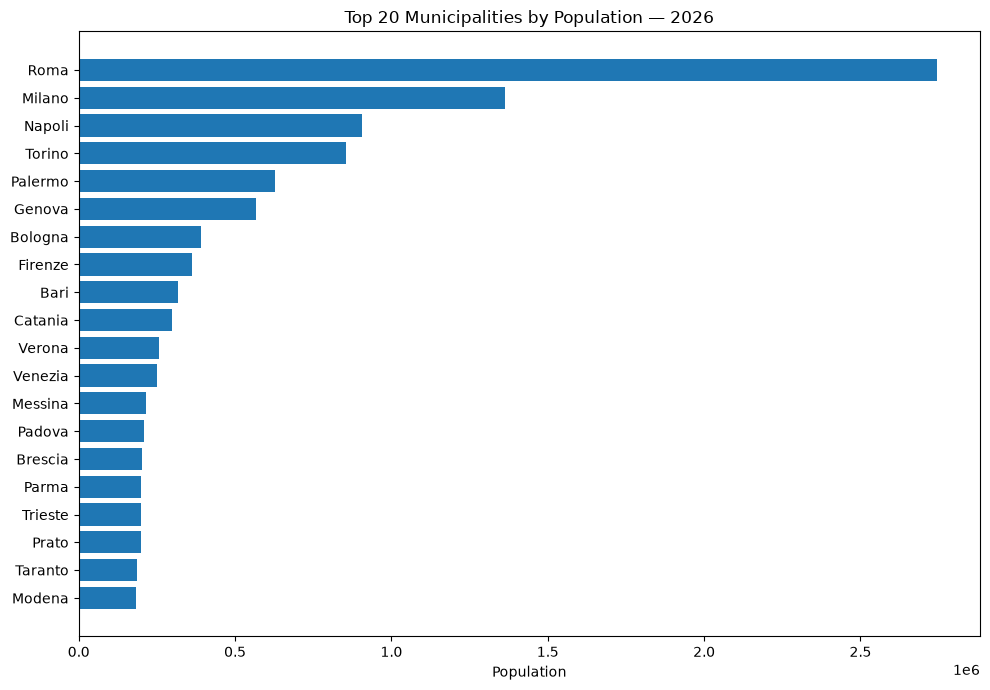

In [6]:
national_latest = latest_dynamics['population'].sum()
top_municipalities = latest_dynamics.sort_values('population', ascending=False).head(20).copy()
top_municipalities['national_share_pct'] = top_municipalities['population'] / national_latest * 100
display(top_municipalities[['municipality','population','national_share_pct']])

fig, ax = plt.subplots(figsize=(10,7))
plot_data = top_municipalities.sort_values('population')
ax.barh(plot_data['municipality'], plot_data['population'])
ax.set_title(f'Top 20 Municipalities by Population — {latest_year}')
ax.set_xlabel('Population')
fig.tight_layout()
plt.show()


## 7. Regional and provincial context

Region and province files are already aggregated by geography. We use their `Età = 999` records for geographic rankings and avoid reconstructing regional mappings from municipality codes.


In [7]:
def load_aggregate_totals(year, level):
    suffix = 'Province' if level == 'province' else 'Regioni'
    path = RAW_DIR / str(year) / f'POSAS_{year}_it_{suffix}.csv'
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig')
    df.columns = [str(c).replace('\ufeff','').strip() for c in df.columns]
    df['Età'] = pd.to_numeric(df['Età'], errors='coerce')
    df['Totale'] = pd.to_numeric(df['Totale'], errors='coerce')
    return df.loc[df['Età'].eq(999)].copy()

latest_regions = load_aggregate_totals(latest_year, 'region')
latest_provinces = load_aggregate_totals(latest_year, 'province')

print('Largest regions')
display(latest_regions.sort_values('Totale', ascending=False).head(10))
print('Largest provinces')
display(latest_provinces.sort_values('Totale', ascending=False).head(10))


Largest regions


,Codice regione,Regione,Età,Totale maschi,Totale femmine,Totale
917,3,Lombardia,999,4967927,5097767,10065694
713,12,Lazio,999,2773837,2935607,5709444
407,15,Campania,999,2725438,2843265,5568703
2039,5,Veneto,999,2399644,2457816,4857460
1529,19,Sicilia,999,2334463,2440731,4775194
509,8,Emilia-Romagna,999,2204044,2272965,4477009
1223,1,Piemonte,999,2086022,2168984,4255006
1325,16,Puglia,999,1890243,1975034,3865277
1631,9,Toscana,999,1786632,1872590,3659222
305,18,Calabria,999,898875,928696,1827571


Largest provinces


,Codice provincia,Provincia,Età,Totale maschi,Totale femmine,Totale
8261,58,Roma,999,2037494,2187407,4224901
5609,15,Milano,999,1591707,1661404,3253111
5915,63,Napoli,999,1438154,1516693,2954847
9485,1,Torino,999,1075124,1129655,2204779
1631,17,Brescia,999,633530,638229,1271759
815,72,Bari,999,595445,622628,1218073
6425,82,Palermo,999,579201,616106,1195307
1223,16,Bergamo,999,558868,560365,1119233
2243,87,Catania,999,520204,547346,1067550
8465,65,Salerno,999,518544,534758,1053302


## 8. Regional age structure

Population size alone does not capture demographic composition. We classify ages into 0–14, 15–64 and 65+ to provide context for housing-demand analysis.


In [8]:
path = RAW_DIR / str(latest_year) / f'POSAS_{latest_year}_it_Regioni.csv'
region_age = pd.read_csv(path, sep=';', encoding='utf-8-sig', usecols=['Regione','Età','Totale'])
region_age['Età'] = pd.to_numeric(region_age['Età'], errors='coerce')
region_age['Totale'] = pd.to_numeric(region_age['Totale'], errors='coerce')
region_age = region_age.loc[region_age['Età'].between(0,100)].copy()
region_age['age_group'] = pd.cut(region_age['Età'], bins=[-1,14,64,100], labels=['0-14','15-64','65+'])

region_age = (
    region_age.groupby(['Regione','age_group'], observed=True)['Totale']
    .sum().reset_index(name='population')
)
region_age['share_pct'] = region_age['population'] / region_age.groupby('Regione')['population'].transform('sum') * 100
age_structure = region_age.pivot(index='Regione', columns='age_group', values='share_pct').reset_index()
display(age_structure.sort_values('65+', ascending=False).head(15))


age_group,Regione,0-14,15-64,65+
7,Liguria,10.13,60.47,29.40
13,Sardegna,9.37,62.54,28.09
5,Friuli-Venezia Giulia,10.63,61.51,27.86
10,Molise,10.21,61.97,27.82
17,Umbria,10.78,61.45,27.77
11,Piemonte,10.94,61.90,27.16
15,Toscana,10.75,62.19,27.06
9,Marche,11.01,62.02,26.97
1,Basilicata,10.62,62.80,26.58
0,Abruzzo,11.12,62.34,26.54


## 9. Analytical hand-off

### Reusable outputs
- `municipality_panel`: one row per municipality-year;
- `national_population`: national population trend and YoY change;
- `latest_dynamics`: latest population level and demographic change;
- `latest_regions` / `latest_provinces`: geographic demographic context;
- `age_structure`: regional demographic composition.

### Next integration

Join this population panel with the validated OMI quotation and transaction panels using a controlled **municipality + reference period/year** key. This enables questions such as whether population growth is associated with stronger price appreciation or transaction activity.

### Interpretation limits

Population change is a contextual indicator, not a causal explanation of real-estate prices or transaction volumes. Results must account for geography, market size, property mix and data coverage.
